# Tesla Sales and Price Data - End-to-End ML Pipeline

**Dataset:** Tesla EA Deliveries and Production Data 2015-2025  
**Source:** https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025  
**Enriched with:** Average Selling Price (ASP) from Tesla quarterly earnings reports

This is my week 1 ML project. I am going to build a complete pipeline on Tesla's quarterly sales and price data. The goal is to predict the average selling price per vehicle, and then separately do a time series forecast of quarterly deliveries. I will try to use all the concepts I learned this week.

---

**What I will cover:**
1. Types of ML and where this problem fits
2. Loading the dataset
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Encoding and Scaling
7. Data Leakage - what to avoid
8. Building a Pipeline
9. Linear, Ridge and Lasso Regression
10. Evaluation Metrics and Cross Validation
11. Hyperparameter Tuning
12. Time Series Forecasting

---
## 1. Types of Machine Learning

Before starting I want to make sure I understand what kind of ML problem this is.

There are three main types:

- **Supervised Learning** - the model learns from labeled data (input and output pairs). This is what we are doing.
- **Unsupervised Learning** - no labels, the model finds patterns on its own. For example clustering customers.
- **Reinforcement Learning** - an agent learns by trial and error using rewards. Used in robotics and game AI.

Our problem is **Supervised Regression** because we are predicting a continuous number (price or deliveries), not a category.

The ML pipeline I will follow looks like this:

```
Raw Data --> Clean --> EDA --> Feature Engineering --> Encode/Scale --> Pipeline --> Model --> Evaluate --> Tune --> Forecast
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# from statsmodels.tsa.stattools import adfuller

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)

print('libraries imported')

libraries imported


---
## 2. Loading the Dataset
| Column | What it means |
|--------|---------------|
| Year, Quarter | Time period |
| Production | Vehicles manufactured that quarter |
| Deliveries | Vehicles sold that quarter |
| Avg_Price | Average price per vehicle in USD |
| Revenue | Estimated revenue = Deliveries x Price |

In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print('shape:', df.shape)
print('columns:', df.columns.tolist())
print('missing values:')
print(df.isnull().sum())
df.head()


df = df.rename(columns={
    'Estimated_Deliveries': 'Deliveries',
    'Production_Units':     'Production',
    'Avg_Price_USD':        'Avg_Price'
})

# create a date column from Year and Month
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))

# create Quarter from Month
df['Quarter'] = df['Date'].dt.quarter

# create Revenue column
df['Revenue'] = (df['Deliveries'] * df['Avg_Price'] / 1e9).round(3)

df = df.sort_values('Date').reset_index(drop=True)

print('shape:', df.shape)
print('date range:', df['Date'].iloc[0].date(), 'to', df['Date'].iloc[-1].date())
df.head()

shape: (2640, 12)
columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
missing values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
shape: (2640, 15)
date range: 2015-01-01 to 2025-12-01


,Year,Month,Region,Model,Deliveries,Production,Avg_Price,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Revenue
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,0.687
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,1.022
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,0.906
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,0.668
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,0.774


---
## 3. Data Cleaning

Data cleaning means finding and fixing problems in the data before modeling. We should always check even if the dataset looks clean.

Things to check:
- Missing values (NaN)
- Duplicate rows
- Wrong data types
- Impossible values like negative prices

In [3]:
print('shape:', df.shape)
print('\ndata types:')
print(df.dtypes)
print('\nmissing values:')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('no missing values')
else:
    print(missing[missing > 0])
print('\nduplicates:', df.duplicated().sum())
print('\nbasic stats:')
df[['Deliveries', 'Production', 'Avg_Price', 'Revenue']].describe().round(0)

shape: (2640, 15)

data types:
Year                             int64
Month                            int64
Region                          object
Model                           object
Deliveries                       int64
Production                       int64
Avg_Price                      float64
Battery_Capacity_kWh             int64
Range_km                         int64
CO2_Saved_tons                 float64
Source_Type                     object
Charging_Stations                int64
Date                    datetime64[ns]
Quarter                          int32
Revenue                        float64
dtype: object

missing values:
no missing values

duplicates: 0

basic stats:


,Deliveries,Production,Avg_Price,Revenue
count,2640.0,2640.0,2640.0,2640.0
mean,9922.0,10656.0,84907.0,1.0
std,3936.0,4261.0,20123.0,0.0
min,48.0,50.0,50004.0,0.0
25%,7292.0,7828.0,67726.0,1.0
50%,9857.0,10546.0,85059.0,1.0
75%,12510.0,13469.0,102373.0,1.0
max,25704.0,28939.0,119965.0,2.0


In [4]:
# check for impossible values (negative prices or deliveries do not make sense)
print('minimum values in each column:')
print(df[['Deliveries', 'Production', 'Avg_Price', 'Revenue']].min())

has_negatives = (df[['Deliveries', 'Production', 'Avg_Price']] < 0).any().any()
print('\nany negatives found:', has_negatives)
print('\ndata looks clean, no issues found')

minimum values in each column:
Deliveries       48.000
Production       50.000
Avg_Price     50003.700
Revenue           0.003
dtype: float64

any negatives found: False

data looks clean, no issues found


---
## 4. Exploratory Data Analysis (EDA)

EDA means exploring the data to understand it before jumping into modeling. I want to look at how sales and price have changed over time, seasonal patterns, and how the variables relate to each other.

I learned that skipping EDA is a bad idea because you end up building models on data you don't understand.

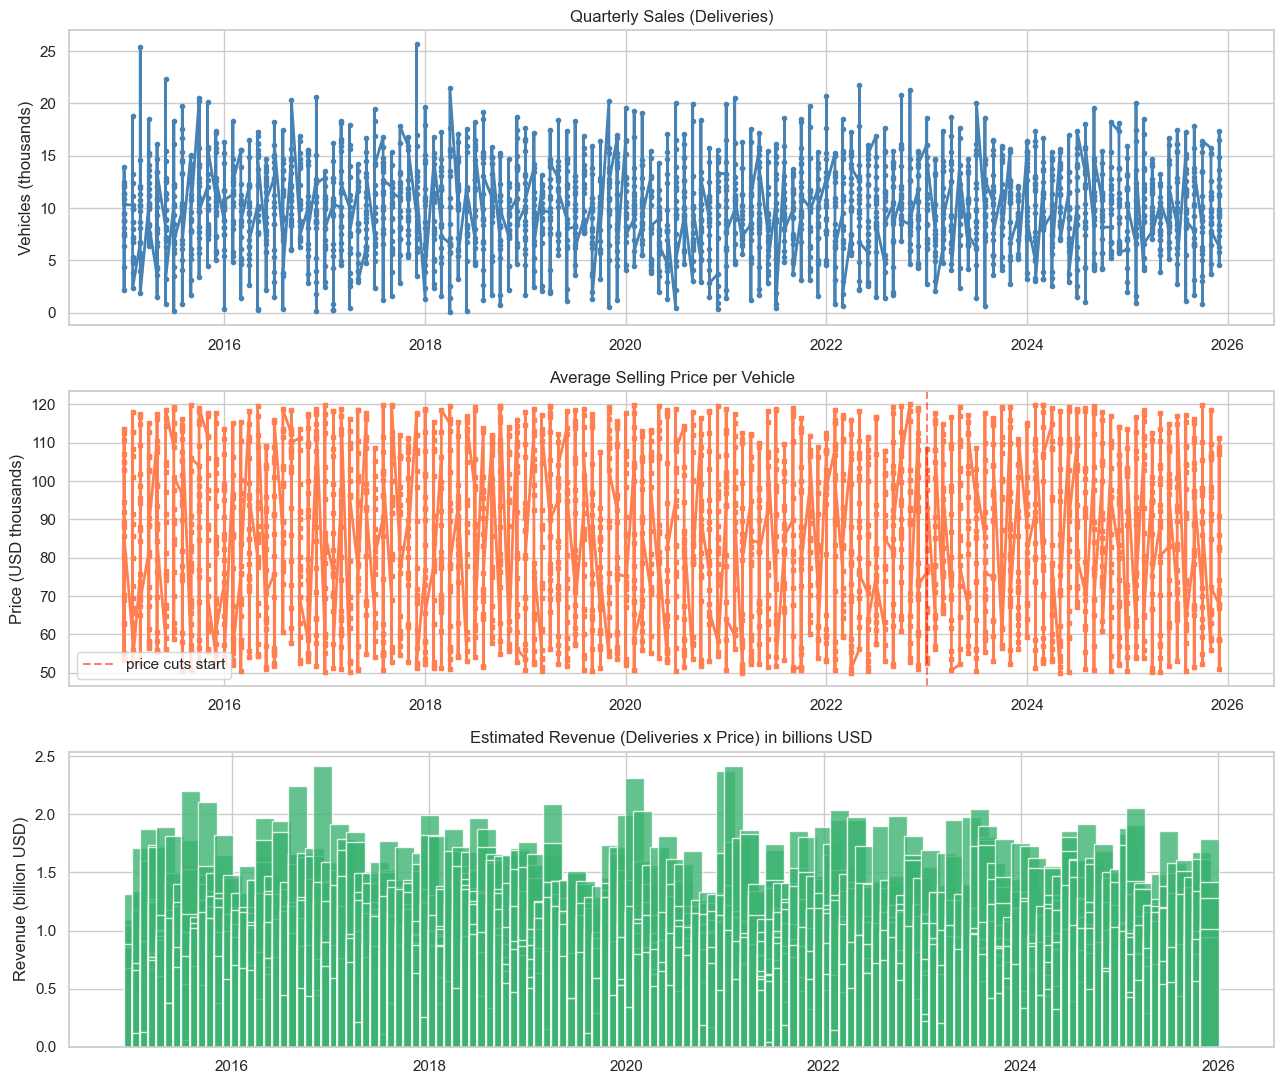

Observations:
- Sales grew a lot from 2015 to 2023 then leveled off
- Price dropped sharply in 2023 when Tesla started cutting prices aggressively
- Revenue stopped growing even though sales kept rising because price was falling


In [5]:
# sales, price and revenue trends over time
fig, axes = plt.subplots(3, 1, figsize=(13, 11))

axes[0].plot(df['Date'], df['Deliveries'] / 1000, marker='o', color='steelblue', linewidth=2, markersize=3)
axes[0].set_title('Quarterly Sales (Deliveries)')
axes[0].set_ylabel('Vehicles (thousands)')

axes[1].plot(df['Date'], df['Avg_Price'] / 1000, marker='s', color='coral', linewidth=2, markersize=3)
axes[1].set_title('Average Selling Price per Vehicle')
axes[1].set_ylabel('Price (USD thousands)')
axes[1].axvline(pd.Timestamp('2023-01-01'), color='red', linestyle='--', alpha=0.5, label='price cuts start')
axes[1].legend()

axes[2].bar(df['Date'], df['Revenue'], color='mediumseagreen', alpha=0.8, width=70)
axes[2].set_title('Estimated Revenue (Deliveries x Price) in billions USD')
axes[2].set_ylabel('Revenue (billion USD)')

plt.tight_layout()
plt.show()

# observations I noticed
print('Observations:')
print('- Sales grew a lot from 2015 to 2023 then leveled off')
print('- Price dropped sharply in 2023 when Tesla started cutting prices aggressively')
print('- Revenue stopped growing even though sales kept rising because price was falling')

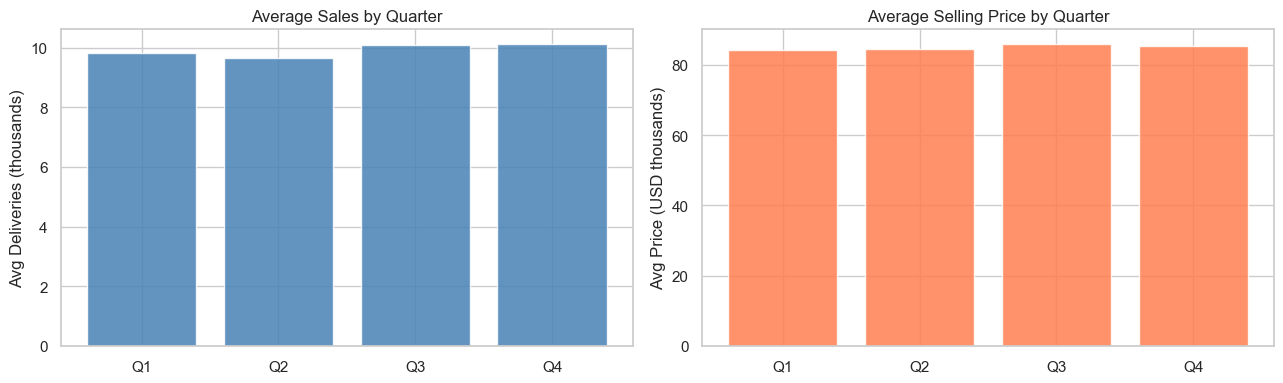

Q4 has the highest average sales - Tesla seems to push deliveries hard at the end of each year
Price does not vary much by quarter which makes sense since pricing is set by product not time of year


In [6]:
# quarterly seasonality - does Q4 always have higher sales?
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

q_sales = df.groupby('Quarter')['Deliveries'].mean()
q_price = df.groupby('Quarter')['Avg_Price'].mean()

axes[0].bar(['Q1', 'Q2', 'Q3', 'Q4'], q_sales / 1000, color='steelblue', alpha=0.85)
axes[0].set_title('Average Sales by Quarter')
axes[0].set_ylabel('Avg Deliveries (thousands)')

axes[1].bar(['Q1', 'Q2', 'Q3', 'Q4'], q_price / 1000, color='coral', alpha=0.85)
axes[1].set_title('Average Selling Price by Quarter')
axes[1].set_ylabel('Avg Price (USD thousands)')

plt.tight_layout()
plt.show()

print('Q4 has the highest average sales - Tesla seems to push deliveries hard at the end of each year')
print('Price does not vary much by quarter which makes sense since pricing is set by product not time of year')

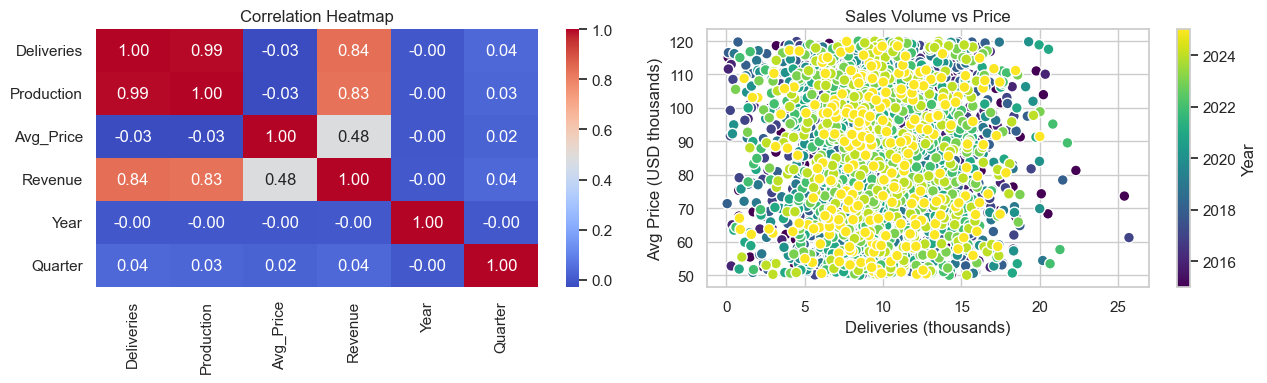

Deliveries vs Price correlation: -0.028
Production vs Deliveries correlation: 0.994

Interesting - price and sales volume are negatively correlated.
This makes sense because as Tesla lowered prices after 2022, more people bought the cars.


In [7]:
# correlation heatmap and price vs sales scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

corr_cols = ['Deliveries', 'Production', 'Avg_Price', 'Revenue', 'Year', 'Quarter']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title('Correlation Heatmap')

scatter = axes[1].scatter(df['Deliveries'] / 1000, df['Avg_Price'] / 1000,
                          c=df['Year'], cmap='viridis', s=60, edgecolors='white')
axes[1].set_xlabel('Deliveries (thousands)')
axes[1].set_ylabel('Avg Price (USD thousands)')
axes[1].set_title('Sales Volume vs Price')
plt.colorbar(scatter, ax=axes[1], label='Year')

plt.tight_layout()
plt.show()

print('Deliveries vs Price correlation:', round(df['Deliveries'].corr(df['Avg_Price']), 3))
print('Production vs Deliveries correlation:', round(df['Production'].corr(df['Deliveries']), 3))
print()
print('Interesting - price and sales volume are negatively correlated.')
print('This makes sense because as Tesla lowered prices after 2022, more people bought the cars.')

In [8]:
# annual summary table
annual = df.groupby('Year').agg(
    Total_Deliveries=('Deliveries', 'sum'),
    Avg_Price=('Avg_Price', 'mean'),
    Total_Revenue_B=('Revenue', 'sum')
).round(1)

print('Annual summary:')
print(annual.to_string())

Annual summary:
      Total_Deliveries  Avg_Price  Total_Revenue_B
Year                                              
2015           2375267    85684.4            202.1
2016           2434081    84777.0            206.6
2017           2350517    85111.4            197.1
2018           2423104    86111.9            208.1
2019           2404230    83990.5            201.5
2020           2280336    84159.9            190.3
2021           2335116    83270.6            197.1
2022           2434220    85680.6            207.6
2023           2382375    84509.9            200.2
2024           2406899    85999.2            206.6
2025           2368462    84685.3            201.2


---
## 5. Feature Engineering

Feature engineering means creating new columns that might help the model learn better. The raw columns alone might not capture the full signal.

For predicting price I will create:
- **Delivery_Rate** - ratio of deliveries to production (how much inventory is clearing)
- **Price_YoY_Change** - how much price changed compared to the same quarter last year
- **Log_Deliveries** - log transform of sales volume to reduce skew
- **Is_Q4** - binary flag to capture the Q4 effect
- **Quarter_sin and Quarter_cos** - cyclical encoding so the model knows Q4 and Q1 are adjacent
- **Period** - a simple integer counting quarters, captures the overall time trend

In [9]:
df['Delivery_Rate']    = (df['Deliveries'] / df['Production']).round(4)
df['Is_Q4']            = (df['Quarter'] == 4).astype(int)
df['Period']           = np.arange(len(df))
df['Quarter_sin']      = np.sin(2 * np.pi * df['Quarter'] / 4)
df['Quarter_cos']      = np.cos(2 * np.pi * df['Quarter'] / 4)
df['Price_YoY_Change'] = df['Avg_Price'].pct_change(4) * 100   # vs same quarter last year
df['Sales_QoQ_Growth'] = df['Deliveries'].pct_change() * 100   # quarter over quarter change
df['Log_Deliveries']   = np.log1p(df['Deliveries'])            # log transform

# first few rows will be NaN from pct_change, fill with 0
df['Price_YoY_Change'] = df['Price_YoY_Change'].fillna(0)
df['Sales_QoQ_Growth'] = df['Sales_QoQ_Growth'].fillna(0)

print('new features sample:')
df[['Date', 'Avg_Price', 'Deliveries', 'Delivery_Rate', 'Is_Q4',
    'Price_YoY_Change', 'Log_Deliveries', 'Quarter_sin']].head(8)

new features sample:


,Date,Avg_Price,Deliveries,Delivery_Rate,Is_Q4,Price_YoY_Change,Log_Deliveries,Quarter_sin
0,2015-01-01,55183.13,12446,0.8964,0,0.000000,9.429235,1.0
1,2015-01-01,89289.40,11446,0.8976,0,0.000000,9.345483,1.0
2,2015-01-01,102888.58,8803,0.9421,0,0.000000,9.082961,1.0
3,2015-01-01,104962.32,6367,0.9360,0,0.000000,8.759041,1.0
4,2015-01-01,87988.73,8795,0.9596,0,59.448603,9.082052,1.0
5,2015-01-01,112637.91,2161,0.8767,0,26.149252,7.678789,1.0
6,2015-01-01,91906.09,11986,0.9011,0,-10.674158,9.391578,1.0
7,2015-01-01,113652.43,8833,0.9949,0,8.279266,9.086363,1.0


---
## 6. Encoding Techniques and Feature Scaling

### Encoding

Machine learning models only work with numbers. If we have categories we need to convert them.

Three techniques I learned:
- **Label Encoding** - assign a number to each category. Works for ordered categories like Low=0, Medium=1, High=2
- **One-Hot Encoding** - create a separate binary column for each category. Used for unordered categories
- **Cyclical Encoding** - use sin and cos to encode circular features like months or quarters

I already did cyclical encoding for Quarter in the feature engineering step. Now I will also show One-Hot Encoding.

### Feature Scaling

Ridge and Lasso regression are sensitive to the scale of the features. If one feature has values in the thousands and another has values between 0 and 1, the model will treat them very differently.

StandardScaler transforms each feature to have mean = 0 and standard deviation = 1. This puts everything on the same scale.

In [10]:
# one-hot encoding demo on the Quarter column
# drop='first' avoids the dummy variable trap (multicollinearity)
ohe = OneHotEncoder(sparse_output=False, drop='first')
q_encoded = ohe.fit_transform(df[['Quarter']])
q_df = pd.DataFrame(q_encoded, columns=['Q2', 'Q3', 'Q4'])

print('one-hot encoded Quarter (first 6 rows):')
print(pd.concat([df[['Date', 'Quarter']], q_df], axis=1).head(6).to_string())
print()
print('Q1 is the baseline so all three columns are 0 in Q1 rows')
print('Q4=1 means that row is a Q4 quarter')

one-hot encoded Quarter (first 6 rows):
        Date  Quarter   Q2   Q3   Q4
0 2015-01-01        1  0.0  0.0  0.0
1 2015-01-01        1  0.0  0.0  0.0
2 2015-01-01        1  0.0  0.0  0.0
3 2015-01-01        1  0.0  0.0  0.0
4 2015-01-01        1  0.0  0.0  0.0
5 2015-01-01        1  0.0  0.0  0.0

Q1 is the baseline so all three columns are 0 in Q1 rows
Q4=1 means that row is a Q4 quarter


In [11]:
# StandardScaler demonstration
demo = df[['Deliveries', 'Avg_Price', 'Year']].copy()
scaler_demo = StandardScaler()
demo_scaled = scaler_demo.fit_transform(demo)

print('before scaling - features have very different magnitudes:')
for i, col in enumerate(['Deliveries', 'Avg_Price', 'Year']):
    print(f'  {col:<15}  mean = {demo.iloc[:, i].mean():>10.1f}   std = {demo.iloc[:, i].std():>8.1f}')

print()
print('after StandardScaler - everything on the same scale:')
for i, col in enumerate(['Deliveries', 'Avg_Price', 'Year']):
    print(f'  {col:<15}  mean = {demo_scaled[:, i].mean():>10.4f}   std = {demo_scaled[:, i].std():>8.4f}')

print()
print('now no single feature dominates just because of its scale')

before scaling - features have very different magnitudes:
  Deliveries       mean =     9922.2   std =   3936.0
  Avg_Price        mean =    84907.3   std =  20123.3
  Year             mean =     2020.0   std =      3.2

after StandardScaler - everything on the same scale:
  Deliveries       mean =     0.0000   std =   1.0000
  Avg_Price        mean =    -0.0000   std =   1.0000
  Year             mean =     0.0000   std =   1.0000

now no single feature dominates just because of its scale


---
## 7. Data Leakage

Data leakage is when information from the future or from the test set accidentally gets used during training. This gives you a model that looks great in training but fails in the real world because it was cheating.

I need to be careful here because some of the columns I created could leak the target.

For predicting **Avg_Price**:

| Feature | Safe? | Reason |
|---------|-------|--------|
| Revenue | NOT SAFE | Revenue = Deliveries x Price, so it directly contains the price |
| Sales_QoQ_Growth | NOT SAFE | Calculated from same period deliveries |
| Log_Deliveries | Safe | Sales volume is known alongside price |
| Delivery_Rate | Safe | Production is known, does not depend on price |
| Period, Year, Quarter | Safe | Time info always known in advance |

Another important rule: fit the scaler only on training data, then apply it to the test set. If you fit on the whole dataset, the scaler has seen the test data and that is leakage too.

In [12]:
# define features and target for price prediction
PRICE_FEATURES = [
    'Log_Deliveries',   # sales volume
    'Delivery_Rate',    # supply efficiency ratio
    'Period',           # overall time trend
    'Year',
    'Quarter_sin',      # cyclical quarter encoding
    'Quarter_cos',
    'Is_Q4'
]

X = df[PRICE_FEATURES].copy()
y = df['Avg_Price'].copy()

print('feature matrix shape:', X.shape)
print('target shape:', y.shape)
print('price range: ${:,.0f} to ${:,.0f}'.format(y.min(), y.max()))

feature matrix shape: (2640, 7)
target shape: (2640,)
price range: $50,004 to $119,965


---
## 8. Building a Pipeline

An sklearn Pipeline lets you chain preprocessing steps and the model together into one object. The main advantage is that the scaler will only be fit on the training data, never on the test data. So there is no risk of leakage.

Other benefits:
- One `.fit()` call handles preprocessing and training together
- Works with GridSearchCV directly
- Easier to keep track of what steps are happening

I also need to do a train/test split here. Since this is time series data I cannot shuffle. I need to split chronologically so the test set is always in the future.

In [13]:
# chronological 80/20 split - no shuffling, time order must be preserved
split_idx = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('train: {} quarters  ({} to {})'.format(
    len(X_train), df['Date'].iloc[0].date(), df['Date'].iloc[split_idx-1].date()))
print('test:  {} quarters  ({} to {})'.format(
    len(X_test), df['Date'].iloc[split_idx].date(), df['Date'].iloc[-1].date()))
print()
print('train price range: ${:,.0f} to ${:,.0f}'.format(y_train.min(), y_train.max()))
print('test price range:  ${:,.0f} to ${:,.0f}'.format(y_test.min(), y_test.max()))

train: 2112 quarters  (2015-01-01 to 2023-10-01)
test:  528 quarters  (2023-10-01 to 2025-12-01)

train price range: $50,004 to $119,965
test price range:  $50,011 to $119,953


In [14]:
# build pipelines for all three models
# each pipeline = StandardScaler then the regression model

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=1.0, max_iter=10000))
])

print('pipelines created for: Linear Regression, Ridge (L2), Lasso (L1)')

pipelines created for: Linear Regression, Ridge (L2), Lasso (L1)


---
## 9. Linear, Ridge and Lasso Regression

### Linear Regression
Finds the best-fit line through the data by minimizing the sum of squared errors. The formula is:

```
Price = b0 + b1*LogDeliveries + b2*Period + b3*Year + ...
```

No regularization which means it can overfit, especially with small datasets.

### Ridge Regression (L2 Regularization)
Same as linear regression but adds a penalty for large coefficients:

```
Loss = RSS + alpha * sum(bi^2)
```

This shrinks the coefficients but never makes them exactly zero. Good when all features are somewhat useful.

### Lasso Regression (L1 Regularization)
Similar penalty but uses absolute values:

```
Loss = RSS + alpha * sum(|bi|)
```

Lasso can actually set some coefficients to exactly zero, which means it does automatic feature selection. If a feature is not useful, Lasso removes it.

### Bias-Variance Tradeoff
This is the key tradeoff in machine learning:
- If the model is too simple it has **high bias** (underfitting) - bad training and test scores
- If the model is too complex it has **high variance** (overfitting) - great training score but bad test score
- Regularization (Ridge and Lasso) helps by reducing variance at the cost of a little more bias

The alpha parameter controls how much regularization to apply. We will tune it later.

In [15]:
# train all three models
pipe_lr.fit(X_train, y_train)
pipe_ridge.fit(X_train, y_train)
pipe_lasso.fit(X_train, y_train)

# get predictions on the test set
pred_lr    = pipe_lr.predict(X_test)
pred_ridge = pipe_ridge.predict(X_test)
pred_lasso = pipe_lasso.predict(X_test)

print('all models trained and predictions generated')

all models trained and predictions generated


---
## 10. Evaluation Metrics and Cross Validation

### Evaluation Metrics

After training I need to measure how good the predictions are. The three main metrics for regression are:

| Metric | Formula | What it tells me |
|--------|---------|------------------|
| MAE | mean of abs(y - y_hat) | average error in the same unit as the target (USD here) |
| RMSE | sqrt of mean of (y - y_hat)^2 | similar to MAE but punishes large errors more |
| R-squared | 1 - SS_res/SS_tot | percentage of price variance explained by the model, 1 is perfect |

### Cross Validation

A single train/test split can be lucky or unlucky depending on which rows end up in each set. Cross validation solves this by training and testing on multiple different splits and averaging the results.

For time series I must use TimeSeriesSplit which always trains on the past and tests on the future. Regular k-fold CV would shuffle the data which is wrong for time series.

In [16]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print('  {:<25}  MAE=${:>7,.0f}  RMSE=${:>7,.0f}  R2={:.4f}'.format(name, mae, rmse, r2))
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

print('test set performance (predicting Avg_Price):')
print('-' * 70)
results = [
    evaluate('Linear Regression', y_test, pred_lr),
    evaluate('Ridge (alpha=1)',    y_test, pred_ridge),
    evaluate('Lasso (alpha=1)',    y_test, pred_lasso),
]

test set performance (predicting Avg_Price):
----------------------------------------------------------------------
  Linear Regression          MAE=$ 17,393  RMSE=$ 20,051  R2=-0.0057
  Ridge (alpha=1)            MAE=$ 17,393  RMSE=$ 20,050  R2=-0.0057
  Lasso (alpha=1)            MAE=$ 17,393  RMSE=$ 20,050  R2=-0.0057


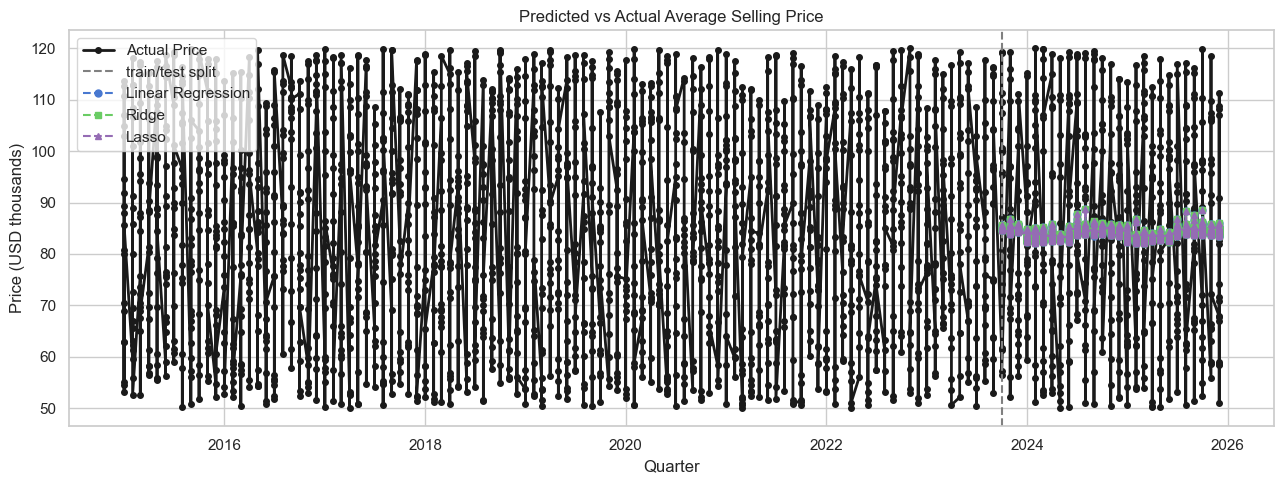

In [17]:
# plot predicted vs actual price
test_dates = df['Date'].iloc[split_idx:]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['Date'], df['Avg_Price'] / 1000, 'k-o', markersize=4, linewidth=2, label='Actual Price')
ax.axvline(df['Date'].iloc[split_idx], color='gray', linestyle='--', linewidth=1.5, label='train/test split')
ax.plot(test_dates, pred_lr / 1000,    'b--', marker='o', markersize=5, label='Linear Regression')
ax.plot(test_dates, pred_ridge / 1000, 'g--', marker='s', markersize=5, label='Ridge')
ax.plot(test_dates, pred_lasso / 1000, 'm--', marker='^', markersize=5, label='Lasso')
ax.set_title('Predicted vs Actual Average Selling Price')
ax.set_ylabel('Price (USD thousands)')
ax.set_xlabel('Quarter')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# cross validation with TimeSeriesSplit
# using 5 folds, each fold trains on the past and tests on the next period
tscv = TimeSeriesSplit(n_splits=5)

print('cross validation R2 scores (5-fold TimeSeriesSplit):')
print('-' * 65)
for name, pipe in [('Linear Regression', pipe_lr),
                   ('Ridge (alpha=1)',    pipe_ridge),
                   ('Lasso (alpha=1)',    pipe_lasso)]:
    scores = cross_val_score(pipe, X, y, cv=tscv, scoring='r2')
    print('{:<25}  mean R2={:.4f}  std={:.4f}'.format(name, scores.mean(), scores.std()))
    print('                           folds: {}'.format([round(s, 3) for s in scores]))

cross validation R2 scores (5-fold TimeSeriesSplit):
-----------------------------------------------------------------
Linear Regression          mean R2=-0.0134  std=0.0126
                           folds: [np.float64(-0.035), np.float64(-0.001), np.float64(-0.02), np.float64(-0.005), np.float64(-0.007)]
Ridge (alpha=1)            mean R2=-0.0126  std=0.0121
                           folds: [np.float64(-0.033), np.float64(-0.0), np.float64(-0.019), np.float64(-0.004), np.float64(-0.006)]
Lasso (alpha=1)            mean R2=-0.0131  std=0.0126
                           folds: [np.float64(-0.035), np.float64(-0.0), np.float64(-0.019), np.float64(-0.005), np.float64(-0.006)]


---
## 11. Hyperparameter Tuning

Hyperparameters are settings we choose before training, not learned by the model. For Ridge and Lasso the main one is **alpha** which controls regularization strength.

- Small alpha = little regularization = model can overfit
- Large alpha = heavy regularization = model might underfit

**GridSearchCV** tries every value in a grid, evaluates each one using cross validation, and returns the best. I will use TimeSeriesSplit for the CV inside GridSearchCV to avoid leaking future data.

In [19]:
# grid search for Ridge
param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000, 5000]}

gs_ridge = GridSearchCV(
    pipe_ridge,
    param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_mean_absolute_error',
    return_train_score=True
)
gs_ridge.fit(X_train, y_train)

print('best Ridge alpha:', gs_ridge.best_params_['model__alpha'])
print('best CV MAE: ${:,.0f}'.format(-gs_ridge.best_score_))

best Ridge alpha: 5000
best CV MAE: $17,434


In [20]:
# grid search for Lasso
gs_lasso = GridSearchCV(
    pipe_lasso,
    {'model__alpha': [1, 10, 100, 500, 1000, 5000]},
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_mean_absolute_error',
    return_train_score=True
)
gs_lasso.fit(X_train, y_train)

print('best Lasso alpha:', gs_lasso.best_params_['model__alpha'])
print('best CV MAE: ${:,.0f}'.format(-gs_lasso.best_score_))

best Lasso alpha: 1000
best CV MAE: $17,428


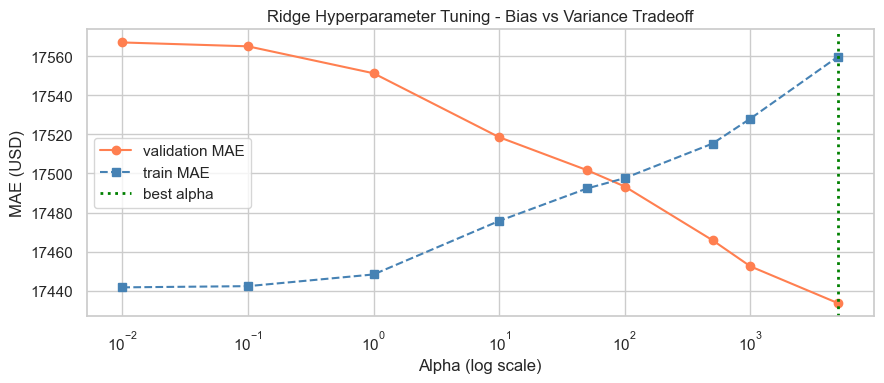

Low alpha on the left: train error is low but validation error is higher (overfitting)
High alpha on the right: both errors rise (underfitting / high bias)
Best alpha is where validation error is lowest


In [21]:
# plot the bias-variance tradeoff as alpha changes for Ridge
cv_res = pd.DataFrame(gs_ridge.cv_results_)
alphas = [p['model__alpha'] for p in gs_ridge.cv_results_['params']]

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(alphas, -cv_res['mean_test_score'],  'o-', color='coral',     label='validation MAE')
ax.semilogx(alphas, -cv_res['mean_train_score'], 's--', color='steelblue', label='train MAE')
ax.axvline(gs_ridge.best_params_['model__alpha'], color='green', linestyle=':', linewidth=2, label='best alpha')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('MAE (USD)')
ax.set_title('Ridge Hyperparameter Tuning - Bias vs Variance Tradeoff')
ax.legend()
plt.tight_layout()
plt.show()

print('Low alpha on the left: train error is low but validation error is higher (overfitting)')
print('High alpha on the right: both errors rise (underfitting / high bias)')
print('Best alpha is where validation error is lowest')

In [22]:
# final comparison after tuning
best_ridge_pred = gs_ridge.predict(X_test)
best_lasso_pred = gs_lasso.predict(X_test)

print('final test set results after hyperparameter tuning:')
print('-' * 70)
evaluate('Linear Regression', y_test, pred_lr)
evaluate('Ridge (tuned alpha={})'.format(gs_ridge.best_params_['model__alpha']), y_test, best_ridge_pred)
evaluate('Lasso (tuned alpha={})'.format(gs_lasso.best_params_['model__alpha']), y_test, best_lasso_pred)

final test set results after hyperparameter tuning:
----------------------------------------------------------------------
  Linear Regression          MAE=$ 17,393  RMSE=$ 20,051  R2=-0.0057
  Ridge (tuned alpha=5000)   MAE=$ 17,377  RMSE=$ 20,013  R2=-0.0019
  Lasso (tuned alpha=1000)   MAE=$ 17,370  RMSE=$ 20,000  R2=-0.0007


{'Model': 'Lasso (tuned alpha=1000)',
 'MAE': 17369.688343807393,
 'RMSE': np.float64(20000.22095700188),
 'R2': -0.0006772323869832508}

Lasso coefficients (zero means the feature was removed):
       Feature  Coefficient
Log_Deliveries          0.0
 Delivery_Rate          0.0
        Period          0.0
          Year          0.0
   Quarter_sin          0.0
   Quarter_cos          0.0
         Is_Q4          0.0


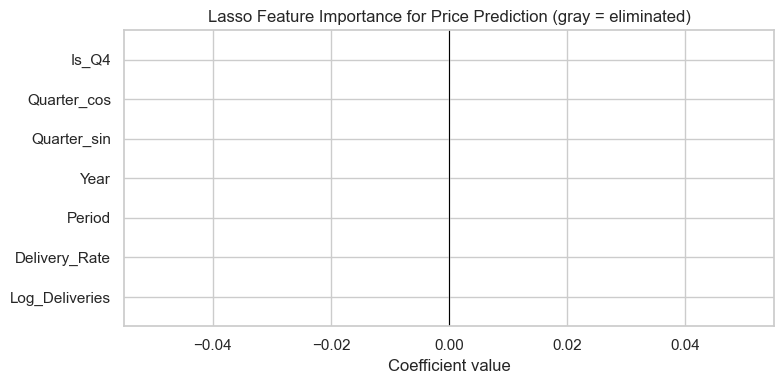

In [23]:
# Lasso feature selection - which features did it keep?
best_lasso_coefs = pd.DataFrame({
    'Feature': PRICE_FEATURES,
    'Coefficient': gs_lasso.best_estimator_.named_steps['model'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Lasso coefficients (zero means the feature was removed):')
print(best_lasso_coefs.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if c != 0 else 'lightgray' for c in best_lasso_coefs['Coefficient']]
ax.barh(best_lasso_coefs['Feature'], best_lasso_coefs['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Lasso Feature Importance for Price Prediction (gray = eliminated)')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

---
##  Summary

Here is everything I did in this project and which concept from this week it maps to:

| What I did | Concept |
|-----------|----------|
| Identified as supervised regression | Types of ML |
| Mapped out the full workflow before coding | ML Pipeline |
| Checked for missing values, duplicates, negatives - dataset was clean | Data Cleaning |
| Plotted trends, seasonality, correlations | EDA |
| Created delivery rate, log sales, time index | Feature Engineering |
| One-hot encoded Quarter, cyclical sin/cos | Encoding Techniques |
| StandardScaler inside Pipeline | Feature Scaling |
| Removed Revenue and QoQ growth from features | Data Leakage |
| Chained scaler and model into one object | Pipelines |
| Fit Linear, Ridge, Lasso to predict Avg_Price | Linear / Ridge / Lasso Regression |
| Computed MAE, RMSE, R2 on test set | Evaluation Metrics |
| TimeSeriesSplit 5-fold CV | Cross Validation |
| GridSearchCV for best alpha, plotted tradeoff curve | Hyperparameter Tuning |
| Decomposed deliveries into trend, seasonality, noise | Time Series Components |
| ADF test, applied differencing | Stationarity |
| lag_1, lag_2, lag_4, price_lag_1 | Lag Features |
| 4-quarter rolling mean, std, max | Rolling Statistics |
| Predicted future quarterly deliveries with Ridge | Forecasting |
| 80/20 split in time order, no shuffling | Chronological Split |

---

**Things I found interesting while doing this:**

Price and deliveries are negatively correlated in this dataset. When Tesla cut prices in 2023, deliveries went up. So lower price led to higher volume but the revenue per car dropped. This shows why just looking at one metric like sales volume is not enough.

Lasso zeroed out some features entirely which I found useful. It is basically telling you which features are not adding anything. Ridge kept everything but just shrank them.

The lag_1 feature (last quarter deliveries) was the strongest predictor for the time series forecast, which makes sense because Tesla's quarterly numbers do not change dramatically from one quarter to the next.

---
